In [2]:
# Day 17 - Decision Tree Depth & Overfitting
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load cleaned data
df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")

# Define features and target
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone"]
X = df[features]
y = df["Survived"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Overfitting Tree (very deep)
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_overfit.fit(X_train, y_train)

# Regular Tree (pruned to prevent overfitting)
tree_regular = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_regular.fit(X_train, y_train)

# Predictions
y_pred_overfit = tree_overfit.predict(X_test)
y_pred_regular = tree_regular.predict(X_test)

# Accuracy Scores
train_acc_overfit = accuracy_score(y_train, tree_overfit.predict(X_train))
test_acc_overfit = accuracy_score(y_test, y_pred_overfit)

train_acc_regular = accuracy_score(y_train, tree_regular.predict(X_train))
test_acc_regular = accuracy_score(y_test, y_pred_regular)

print("Overfitting Tree:")
print(f"  Training Accuracy: {train_acc_overfit * 100:.2f} %")
print(f"  Test Accuracy: {test_acc_overfit * 100:.2f} %")

print("\nRegular Tree:")
print(f"  Training Accuracy: {train_acc_regular * 100:.2f} %")
print(f"  Test Accuracy: {test_acc_regular * 100:.2f} %")



Overfitting Tree:
  Training Accuracy: 98.03 %
  Test Accuracy: 78.21 %

Regular Tree:
  Training Accuracy: 83.43 %
  Test Accuracy: 79.89 %


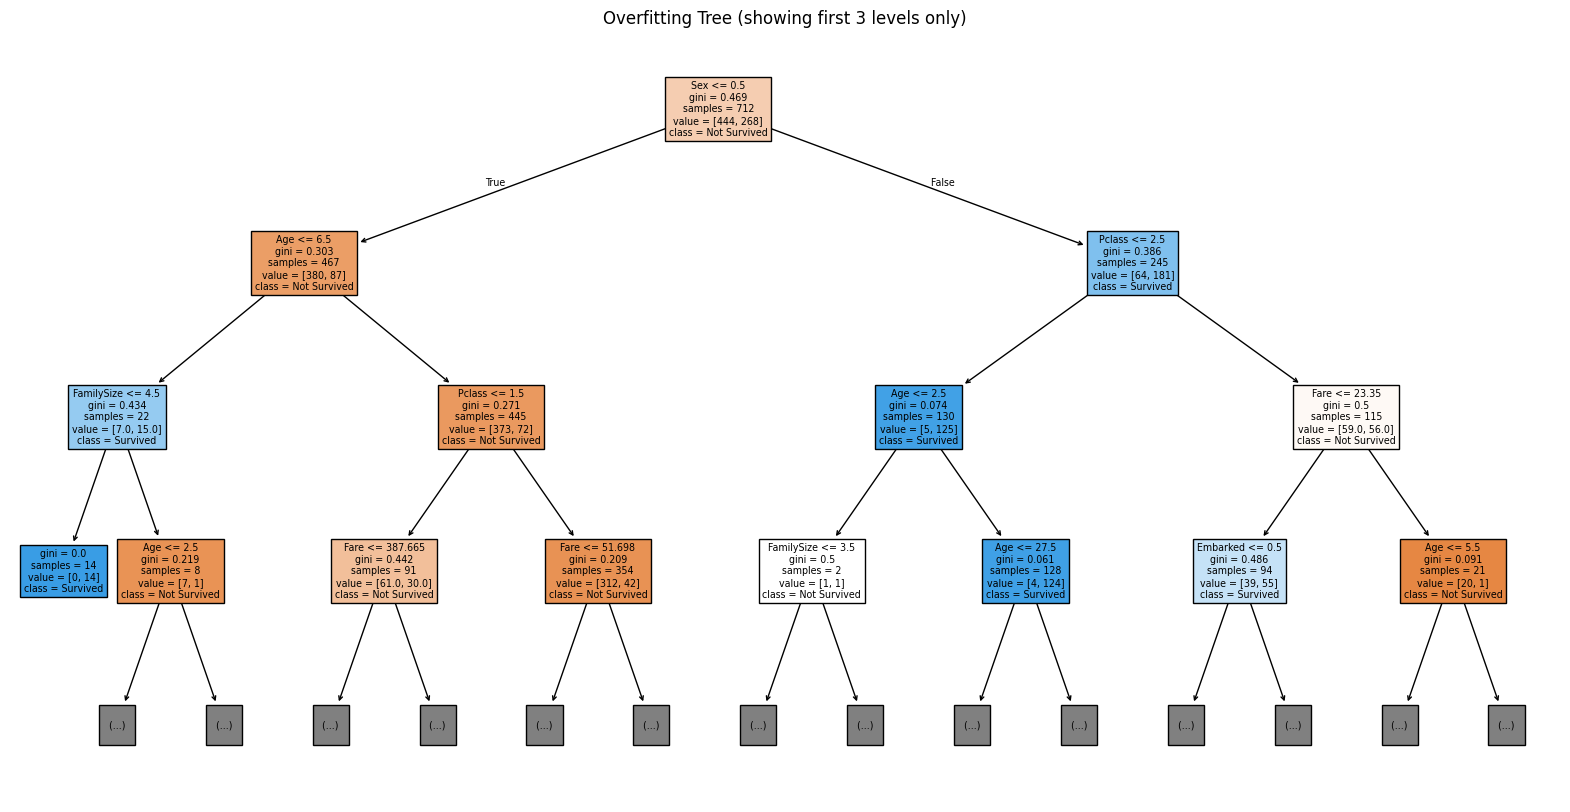

In [3]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(tree_overfit, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True, max_depth=3)
plt.title("Overfitting Tree (showing first 3 levels only)")
plt.show()

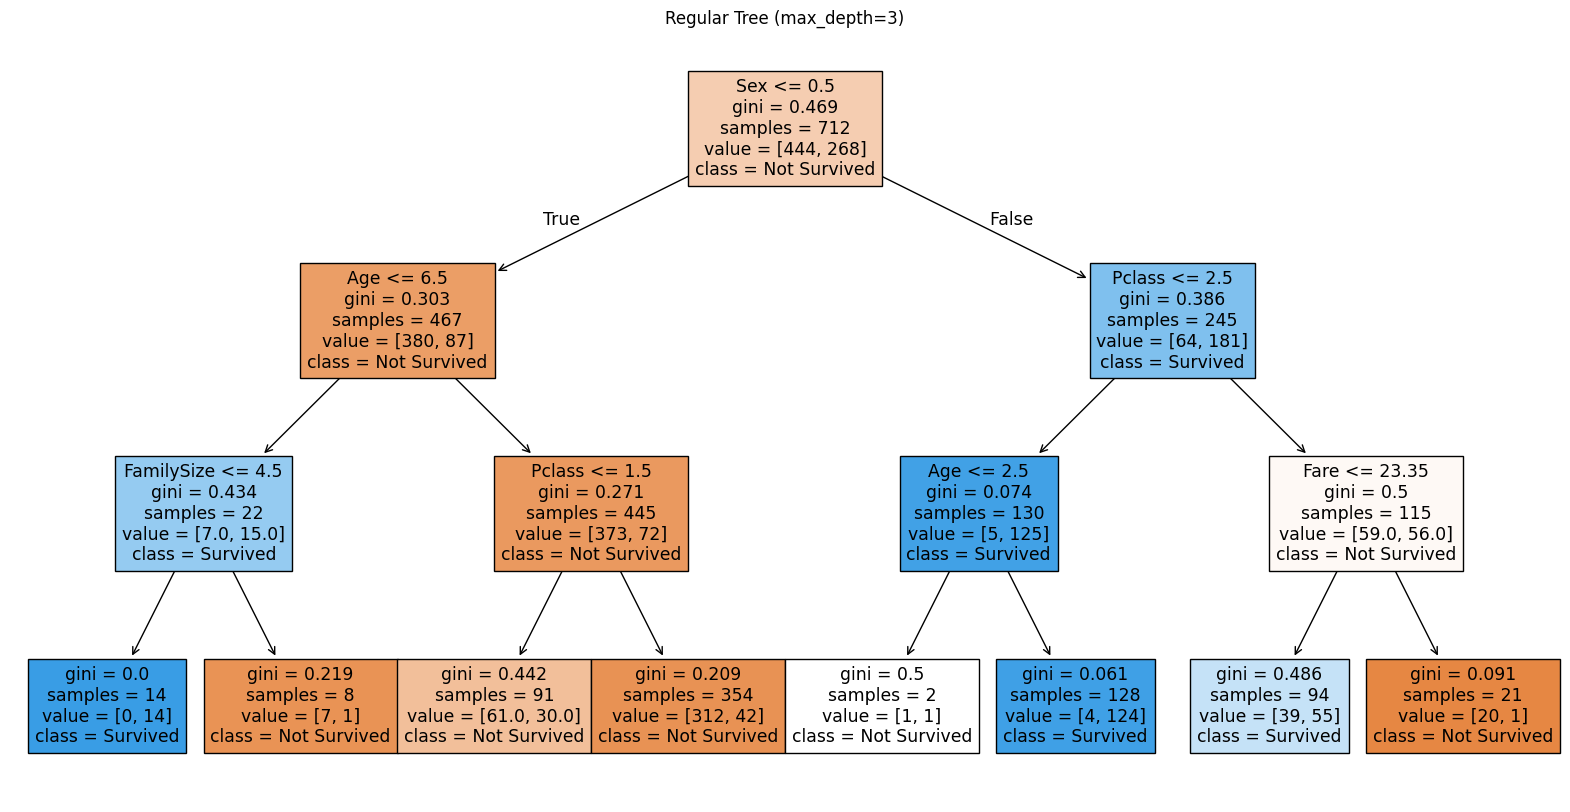

In [4]:
plt.figure(figsize=(20, 10))
plot_tree(tree_regular, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.title("Regular Tree (max_depth=3)")
plt.show()
